#  LlamaIndex — Excel Parsing & Graphs

This notebook demonstrates how to:
1. **Generate** a realistic Excel dataset (sales data)
2. **Parse** it with LlamaIndex's `PandasExcelReader`
3. **Index & query** the data using LlamaIndex (no OpenAI key needed — uses `MockLLM`)
4. **Visualise** the data with matplotlib / seaborn

---

## 0 — Install dependencies

In [1]:
# Run once; skip if already installed
!pip install llama-index llama-index-readers-file openpyxl matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.3/336.3 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 7.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


## 1 — Create a sample Excel file

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

np.random.seed(42)

# ── Sheet 1: Monthly Sales ──────────────────────────────────────────────────
months = pd.date_range('2023-01-01', periods=12, freq='MS').strftime('%b %Y').tolist()
products = ['Widget A', 'Widget B', 'Widget C']

sales_data = {
    'Month': months,
    'Widget A': np.random.randint(120, 300, 12),
    'Widget B': np.random.randint(80,  220, 12),
    'Widget C': np.random.randint(50,  180, 12),
}
df_sales = pd.DataFrame(sales_data)
df_sales['Total'] = df_sales[products].sum(axis=1)

# ── Sheet 2: Regional Performance ──────────────────────────────────────────
regions = ['North', 'South', 'East', 'West']
df_regions = pd.DataFrame({
    'Region':  regions,
    'Revenue': np.random.randint(50_000, 200_000, 4),
    'Costs':   np.random.randint(20_000,  80_000, 4),
})
df_regions['Profit'] = df_regions['Revenue'] - df_regions['Costs']
df_regions['Margin %'] = (df_regions['Profit'] / df_regions['Revenue'] * 100).round(1)

# ── Sheet 3: Product Ratings ────────────────────────────────────────────────
df_ratings = pd.DataFrame({
    'Product':   products,
    'Rating':    [4.3, 3.8, 4.7],
    'Reviews':   [340, 210, 480],
    'NPS Score': [62,  45,  78],
})

# ── Save ──────────────────────────────────────────────────────────────────
EXCEL_PATH = Path('sample_data.xlsx')
with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as writer:
    df_sales.to_excel(writer,   sheet_name='Monthly Sales',       index=False)
    df_regions.to_excel(writer, sheet_name='Regional Performance', index=False)
    df_ratings.to_excel(writer, sheet_name='Product Ratings',      index=False)

print(f'✅ Excel file saved → {EXCEL_PATH.resolve()}')
print(f'   Sheets: Monthly Sales | Regional Performance | Product Ratings')

✅ Excel file saved → /content/sample_data.xlsx
   Sheets: Monthly Sales | Regional Performance | Product Ratings


## 2 — Parse Excel with LlamaIndex `PandasExcelReader`

In [3]:
from llama_index.readers.file import PandasExcelReader

reader = PandasExcelReader()
documents = reader.load_data(file=EXCEL_PATH)

print(f'📄 Loaded {len(documents)} document(s) from Excel\n')
for i, doc in enumerate(documents):
    preview = doc.text[:300].replace('\n', ' ')
    print(f'--- Document {i} ---')
    print(f'  Metadata : {doc.metadata}')
    print(f'  Text (preview): {preview}...')
    print()

📄 Loaded 3 document(s) from Excel

--- Document 0 ---
  Metadata : {}
  Text (preview): Month: Jan 2023, Widget A: 222, Widget B: 179, Widget C: 98, Total: 499 Month: Feb 2023, Widget A: 299, Widget B: 183, Widget C: 108, Total: 590 Month: Mar 2023, Widget A: 212, Widget B: 210, Widget C: 64, Total: 486 Month: Apr 2023, Widget A: 134, Widget B: 132, Widget C: 100, Total: 366 Month: May...

--- Document 1 ---
  Metadata : {}
  Text (preview): Region: North, Revenue: 118148, Costs: 68555, Profit: 49593, Margin %: 42.0 Region: South, Revenue: 174243, Costs: 79900, Profit: 94343, Margin %: 54.1 Region: East, Revenue: 170174, Costs: 37159, Profit: 133015, Margin %: 78.2 Region: West, Revenue: 174358, Costs: 64974, Profit: 109384, Margin %: 6...

--- Document 2 ---
  Metadata : {}
  Text (preview): Product: Widget A, Rating: 4.3, Reviews: 340, NPS Score: 62 Product: Widget B, Rating: 3.8, Reviews: 210, NPS Score: 45 Product: Widget C, Rating: 4.7, Reviews: 480, NPS Score: 78...



### 2b — Load each sheet individually

In [4]:
# Load specific sheet by name
reader_sheet = PandasExcelReader(sheet_name='Monthly Sales')
docs_sales = reader_sheet.load_data(file=EXCEL_PATH)

print('Monthly Sales sheet as LlamaIndex document:')
print(docs_sales[0].text[:600])

Monthly Sales sheet as LlamaIndex document:
Month: Jan 2023, Widget A: 222, Widget B: 179, Widget C: 98, Total: 499
Month: Feb 2023, Widget A: 299, Widget B: 183, Widget C: 108, Total: 590
Month: Mar 2023, Widget A: 212, Widget B: 210, Widget C: 64, Total: 486
Month: Apr 2023, Widget A: 134, Widget B: 132, Widget C: 100, Total: 366
Month: May 2023, Widget A: 226, Widget B: 81, Widget C: 157, Total: 464
Month: Jun 2023, Widget A: 191, Widget B: 167, Widget C: 104, Total: 462
Month: Jul 2023, Widget A: 140, Widget B: 117, Widget C: 113, Total: 370
Month: Aug 2023, Widget A: 222, Widget B: 209, Widget C: 100, Total: 531
Month: Sep 2023, Wi


## 3 — Build a VectorStore Index (MockLLM — no API key needed)

In [5]:
from llama_index.core import VectorStoreIndex, Settings
from llama_index.core.llms.mock import MockLLM
from llama_index.core.embeddings import resolve_embed_model

# Use MockLLM so no OpenAI key is required for this demo
Settings.llm = MockLLM(max_tokens=256)

# Use a simple local embedding (or swap for openai/huggingface)
# Falls back to a lightweight default
try:
    from llama_index.embeddings.huggingface import HuggingFaceEmbedding
    Settings.embed_model = HuggingFaceEmbedding(model_name='BAAI/bge-small-en-v1.5')
    print('Using HuggingFace embeddings')
except Exception:
    from llama_index.core.embeddings.mock_embed_model import MockEmbedding
    Settings.embed_model = MockEmbedding(embed_dim=8)
    print('Using MockEmbedding (no model download needed)')

index = VectorStoreIndex.from_documents(documents)
print(f'\n✅ Index built with {len(documents)} document(s)')

Using MockEmbedding (no model download needed)

✅ Index built with 3 document(s)


In [6]:
# Query the index — with a real LLM this returns an AI-generated answer
query_engine = index.as_query_engine(similarity_top_k=2)
response = query_engine.query('What are the total sales by product?')

print('Query: What are the total sales by product?')
print(f'Response (MockLLM): {response}')
print('\n💡 Swap MockLLM for OpenAI / Anthropic to get real AI answers')

Query: What are the total sales by product?
Response (MockLLM): text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text text t

## 4 — Direct Pandas Analysis

In [7]:
# Load all sheets into a dict
sheets = pd.read_excel(EXCEL_PATH, sheet_name=None)

df_s = sheets['Monthly Sales']
df_r = sheets['Regional Performance']
df_p = sheets['Product Ratings']

print('=== Monthly Sales ===')
display(df_s.head())

print('\n=== Regional Performance ===')
display(df_r)

print('\n=== Product Ratings ===')
display(df_p)

=== Monthly Sales ===


,Month,Widget A,Widget B,Widget C,Total
0,Jan 2023,222,179,98,499
1,Feb 2023,299,183,108,590
2,Mar 2023,212,210,64,486
3,Apr 2023,134,132,100,366
4,May 2023,226,81,157,464



=== Regional Performance ===


,Region,Revenue,Costs,Profit,Margin %
0,North,118148,68555,49593,42.0
1,South,174243,79900,94343,54.1
2,East,170174,37159,133015,78.2
3,West,174358,64974,109384,62.7



=== Product Ratings ===


,Product,Rating,Reviews,NPS Score
0,Widget A,4.3,340,62
1,Widget B,3.8,210,45
2,Widget C,4.7,480,78


## 5 — Visualisations

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

COLORS = ['#4C72B0', '#DD8452', '#55A868']

### 5a — Stacked Bar: Monthly Sales by Product

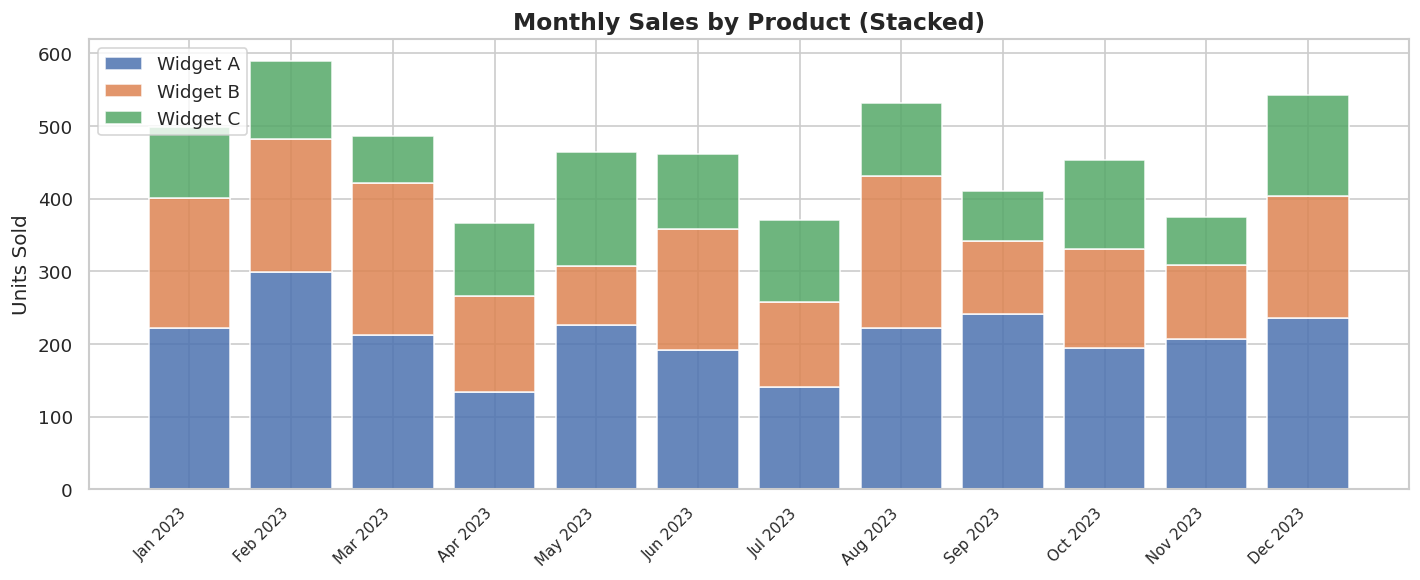

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(df_s['Month']))
bottom = np.zeros(len(df_s))

for col, color in zip(products, COLORS):
    ax.bar(x, df_s[col], bottom=bottom, label=col, color=color, alpha=0.85, edgecolor='white')
    bottom += df_s[col].values

ax.set_xticks(list(x))
ax.set_xticklabels(df_s['Month'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Units Sold')
ax.set_title('Monthly Sales by Product (Stacked)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
plt.tight_layout()
plt.savefig('chart_monthly_stacked.png')
plt.show()

### 5b — Line Chart: Monthly Totals with Trend

/tmp/ipykernel_29437/2300561411.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df_s['Month'], rotation=45, ha='right', fontsize=8)
/tmp/ipykernel_29437/2300561411.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_s['Month'], rotation=45, ha='right', fontsize=8)


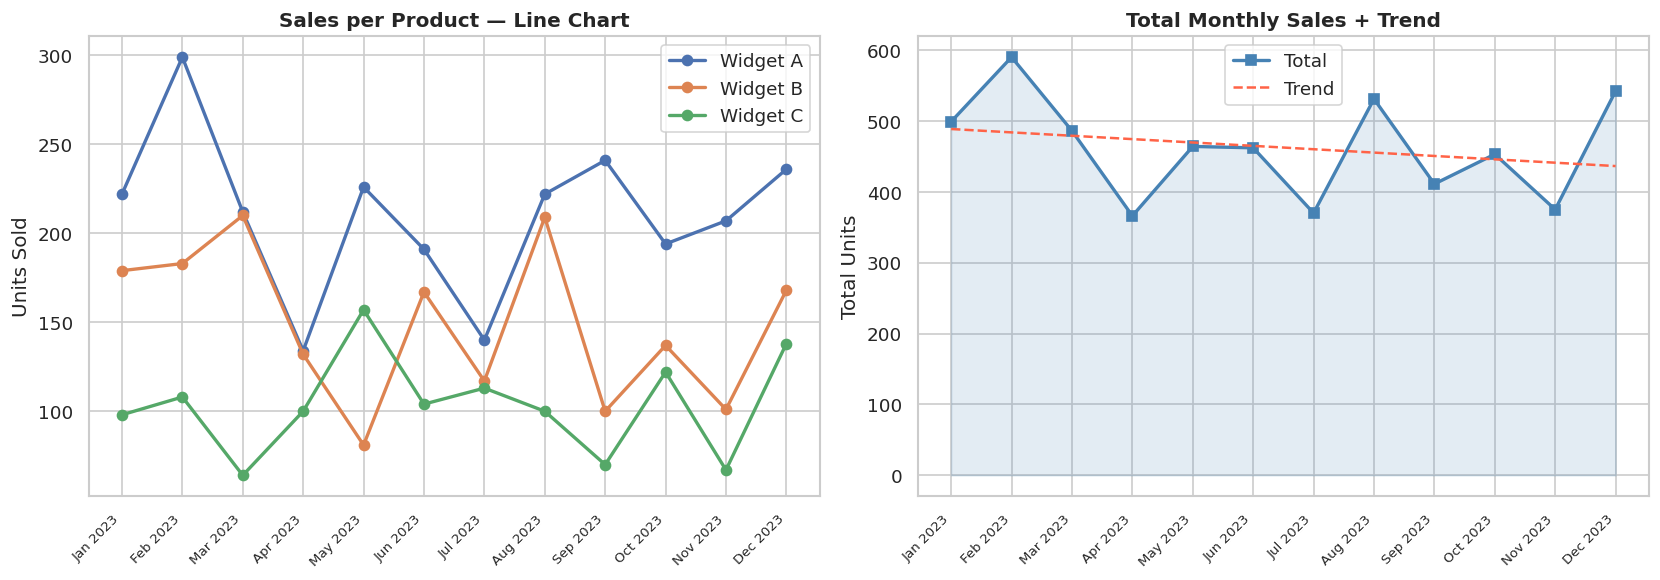

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual product lines
for col, color in zip(products, COLORS):
    axes[0].plot(df_s['Month'], df_s[col], marker='o', label=col, color=color, linewidth=2)
axes[0].set_xticklabels(df_s['Month'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Units Sold')
axes[0].set_title('Sales per Product — Line Chart', fontweight='bold')
axes[0].legend()

# Right: total with linear trend
axes[1].plot(df_s['Month'], df_s['Total'], marker='s', color='steelblue', linewidth=2, label='Total')
z = np.polyfit(range(len(df_s)), df_s['Total'], 1)
p = np.poly1d(z)
axes[1].plot(df_s['Month'], p(range(len(df_s))), '--', color='tomato', linewidth=1.5, label='Trend')
axes[1].fill_between(df_s['Month'], df_s['Total'], alpha=0.15, color='steelblue')
axes[1].set_xticklabels(df_s['Month'], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Total Units')
axes[1].set_title('Total Monthly Sales + Trend', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart_monthly_lines.png')
plt.show()

### 5c — Regional Revenue, Costs & Profit

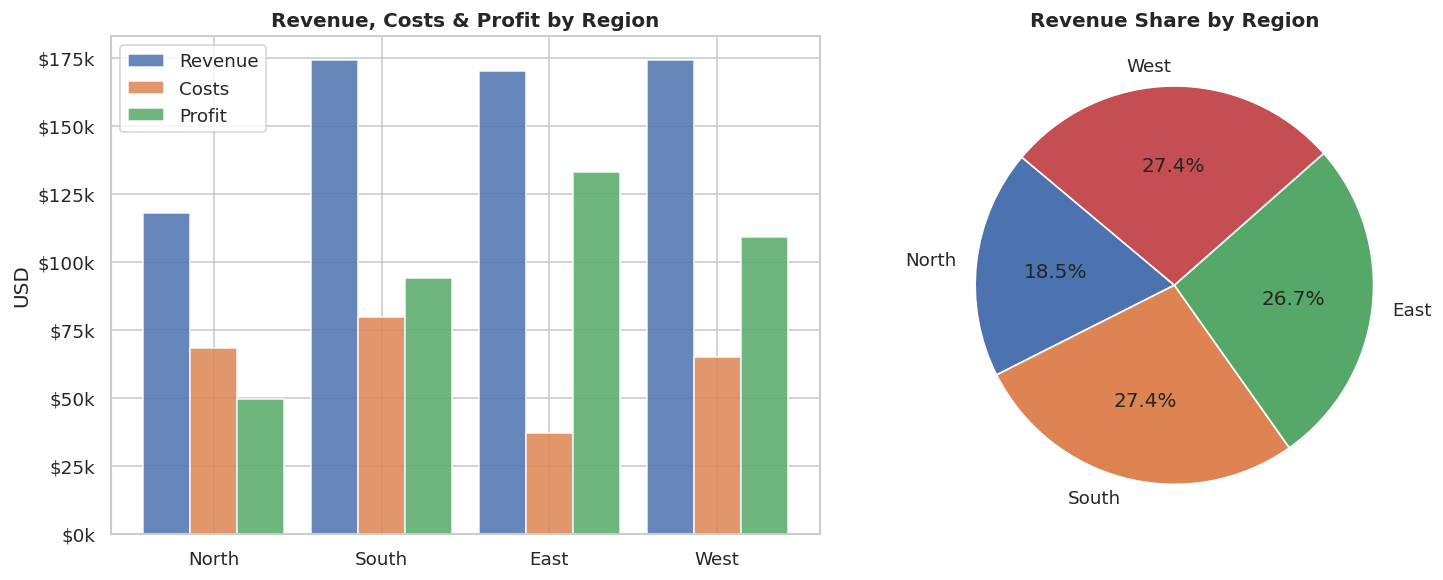

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grouped bar
x = np.arange(len(regions))
w = 0.28
axes[0].bar(x - w, df_r['Revenue'], width=w, label='Revenue', color='#4C72B0', alpha=0.85)
axes[0].bar(x,     df_r['Costs'],   width=w, label='Costs',   color='#DD8452', alpha=0.85)
axes[0].bar(x + w, df_r['Profit'],  width=w, label='Profit',  color='#55A868', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(regions)
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v/1000:.0f}k'))
axes[0].set_title('Revenue, Costs & Profit by Region', fontweight='bold')
axes[0].legend()

# Pie: revenue share
axes[1].pie(df_r['Revenue'], labels=regions, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
            startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Revenue Share by Region', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_regional.png')
plt.show()

### 5d — Product Ratings Dashboard

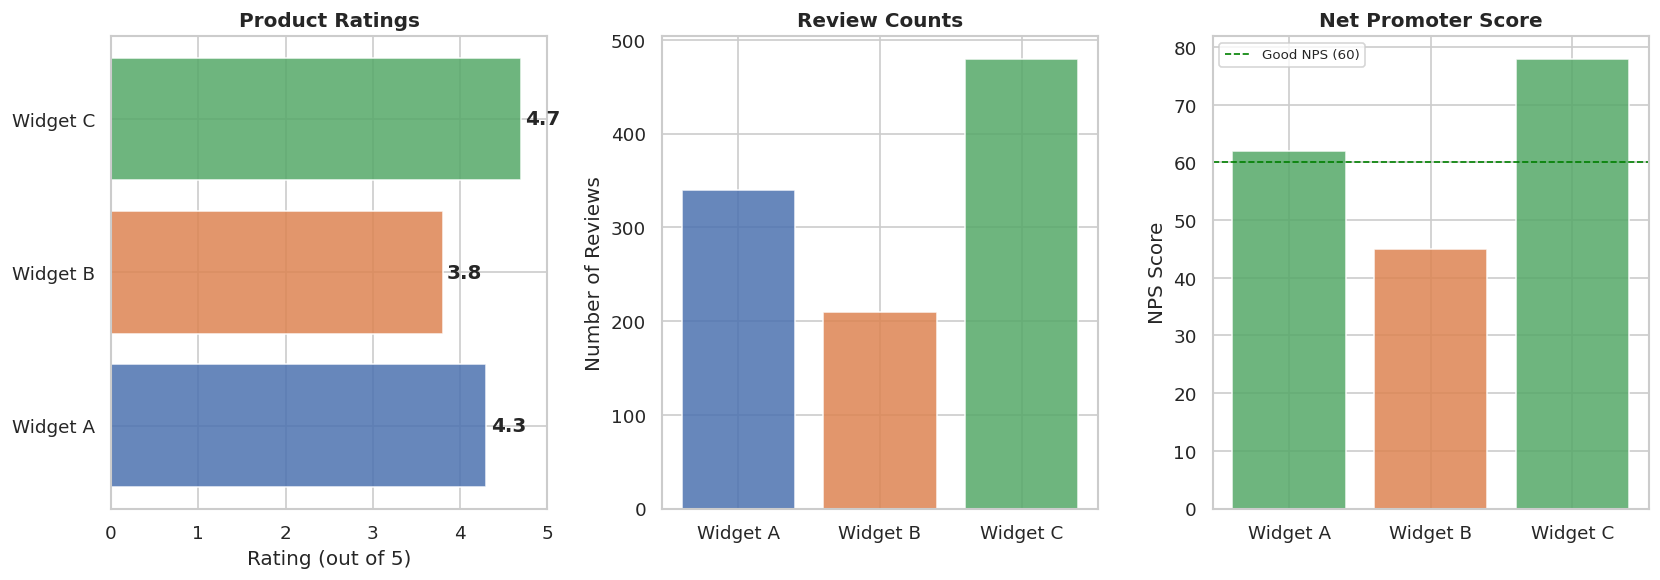

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Rating bars
bars = axes[0].barh(df_p['Product'], df_p['Rating'], color=COLORS, alpha=0.85, edgecolor='white')
axes[0].set_xlim(0, 5)
axes[0].set_xlabel('Rating (out of 5)')
axes[0].set_title('Product Ratings', fontweight='bold')
for bar, v in zip(bars, df_p['Rating']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{v}', va='center', fontweight='bold')

# Review counts
axes[1].bar(df_p['Product'], df_p['Reviews'], color=COLORS, alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Number of Reviews')
axes[1].set_title('Review Counts', fontweight='bold')

# NPS scores
colors_nps = ['#55A868' if n >= 60 else '#DD8452' if n >= 40 else '#C44E52' for n in df_p['NPS Score']]
axes[2].bar(df_p['Product'], df_p['NPS Score'], color=colors_nps, alpha=0.85, edgecolor='white')
axes[2].axhline(y=60, color='green', linestyle='--', linewidth=1, label='Good NPS (60)')
axes[2].set_ylabel('NPS Score')
axes[2].set_title('Net Promoter Score', fontweight='bold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('chart_ratings.png')
plt.show()

### 5e — Heatmap: Monthly Sales Correlation

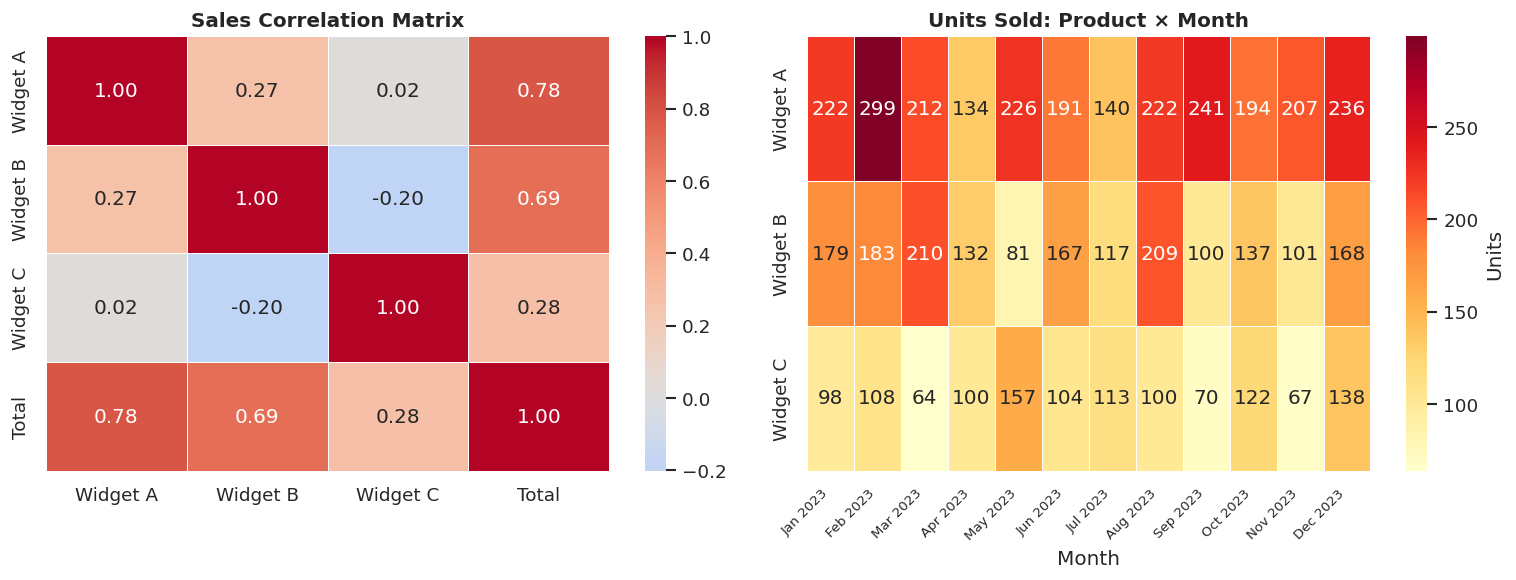

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Correlation heatmap
corr = df_s[products + ['Total']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Sales Correlation Matrix', fontweight='bold')

# Monthly heat map (month × product)
heat_data = df_s.set_index('Month')[products]
sns.heatmap(heat_data.T, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.4, ax=axes[1], cbar_kws={'label': 'Units'})
axes[1].set_title('Units Sold: Product × Month', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('chart_heatmap.png')
plt.show()

## 6 — Summary Statistics

In [14]:
print('=== Monthly Sales Summary ===')
display(df_s[products + ['Total']].describe().round(1))

print('\n=== Best Month ===')
best_idx = df_s['Total'].idxmax()
print(df_s.loc[best_idx, ['Month', 'Total']].to_string())

print('\n=== Regional Margin Summary ===')
display(df_r[['Region', 'Revenue', 'Profit', 'Margin %']].sort_values('Margin %', ascending=False))

print('\n=== Top Rated Product ===')
top = df_p.loc[df_p['Rating'].idxmax()]
print(f"{top['Product']}  —  Rating: {top['Rating']} | NPS: {top['NPS Score']}")

=== Monthly Sales Summary ===


,Widget A,Widget B,Widget C,Total
count,12.0,12.0,12.0,12.0
mean,210.3,148.7,103.4,462.4
std,44.1,43.5,27.9,72.3
min,134.0,81.0,64.0,366.0
25%,193.2,113.0,91.0,402.0
50%,217.0,152.0,102.0,463.0
75%,228.5,180.0,115.2,507.0
max,299.0,210.0,157.0,590.0



=== Best Month ===
Month    Feb 2023
Total         590

=== Regional Margin Summary ===


,Region,Revenue,Profit,Margin %
2,East,170174,133015,78.2
3,West,174358,109384,62.7
1,South,174243,94343,54.1
0,North,118148,49593,42.0



=== Top Rated Product ===
Widget C  —  Rating: 4.7 | NPS: 78


In [16]:
from llama_index.core import VectorStoreIndex, Settings
from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding

API_KEY = "sk-proj-"  # your key

# ✅ Both LLM and embedding must use the same provider
Settings.llm = OpenAI(model="gpt-4o-mini", api_key=API_KEY)
Settings.embed_model = OpenAIEmbedding(model="text-embedding-3-small", api_key=API_KEY)

# Rebuild the index with real embeddings
index = VectorStoreIndex.from_documents(documents)
query_engine = index.as_query_engine(similarity_top_k=3)

response = query_engine.query("Which region has the best profit margin, and why might that be?")
print(response)

The region with the best profit margin is the East, which has a margin of 78.2%. This high margin could be attributed to lower costs relative to revenue, resulting in a significantly higher profit compared to other regions.


In [17]:
# --- Sources ---
print("\n" + "=" * 60)
print("WHERE IT GOT THAT FROM")
print("=" * 60)
for i, node in enumerate(response.source_nodes):
    print(f"\n📄 Source {i+1}  (score: {node.score:.3f})")
    print(f"   Metadata : {node.metadata}")
    print(f"   Text     : {node.text[:400]}...")


WHERE IT GOT THAT FROM

📄 Source 1  (score: 0.608)
   Metadata : {}
   Text     : Region: North, Revenue: 118148, Costs: 68555, Profit: 49593, Margin %: 42.0
Region: South, Revenue: 174243, Costs: 79900, Profit: 94343, Margin %: 54.1
Region: East, Revenue: 170174, Costs: 37159, Profit: 133015, Margin %: 78.2
Region: West, Revenue: 174358, Costs: 64974, Profit: 109384, Margin %: 62.7...

📄 Source 2  (score: 0.212)
   Metadata : {}
   Text     : Product: Widget A, Rating: 4.3, Reviews: 340, NPS Score: 62
Product: Widget B, Rating: 3.8, Reviews: 210, NPS Score: 45
Product: Widget C, Rating: 4.7, Reviews: 480, NPS Score: 78...

📄 Source 3  (score: 0.196)
   Metadata : {}
   Text     : Month: Jan 2023, Widget A: 222, Widget B: 179, Widget C: 98, Total: 499
Month: Feb 2023, Widget A: 299, Widget B: 183, Widget C: 108, Total: 590
Month: Mar 2023, Widget A: 212, Widget B: 210, Widget C: 64, Total: 486
Month: Apr 2023, Widget A: 134, Widget B: 132, Widget C: 100, Total: 366
Month: May 2023, Wi